## Import Labraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Read the Online Retail Dataset

In [2]:
df=pd.read_csv("online_retail_II.csv")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## Inspect the dataset

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [5]:
df.shape

(1067371, 8)

In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [9]:
df.nunique()

Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

## Data Cleaning
## 1.Missing Values


In [10]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [11]:
df["Description"] = df["Description"].fillna("Unknown")
df.isnull().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [12]:
#Null Customer Percentage
null_percent=(df['Customer ID'].isnull().sum()/len(df))*100
print("Percentage of orders with no Customer Id is:",null_percent.round(2))

Percentage of orders with no Customer Id is: 22.77


## 2.Duplicates

In [13]:
df.duplicated().sum()

np.int64(34335)

In [14]:
duplicates=df[df.duplicated()]
duplicates.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom


In [15]:
df[df.duplicated(keep=False)].sort_values(by="Invoice").head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.00,United Kingdom
388,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.00,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom


In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

## Data Types

In [18]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [19]:
#InvoiceDate str to Date
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [20]:
df.dtypes

Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

In [21]:
#Customer ID float to int

In [22]:
df['Customer ID']=df['Customer ID'].astype("Int64")
df['Customer ID'].dtype

Int64Dtype()

In [23]:
df['Price'].isna().sum()

np.int64(0)

## Invalid Values

In [24]:
df['Price'].describe()

count   1033036.00
mean          4.61
std         122.40
min      -53594.36
25%           1.25
50%           2.10
75%           4.15
max       38970.00
Name: Price, dtype: float64

In [25]:
df['Quantity'].describe()

count   1033036.00
mean         10.08
std         175.20
min      -80995.00
25%           1.00
50%           3.00
75%          10.00
max       80995.00
Name: Quantity, dtype: float64

## Maximum Price

In [26]:
df['Price'].max()

np.float64(38970.0)

## Minimum Price



In [27]:
df['Price'].min()

np.float64(-53594.36)

In [28]:
neg_amount=df[df['Price']<0]
neg_amount

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,<NA>,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,<NA>,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,<NA>,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom


In [29]:
#Total Negatives
(df["Price"] < 0).sum()

np.int64(5)

In [30]:
total_loss = neg_amount['Price'].sum()
print(total_loss)


-158676.13999999998


## Maximum Quantity


In [31]:
df['Quantity'].max()

np.int64(80995)

## Minimum Quantity


In [32]:
df['Quantity'].min()

np.int64(-80995)

In [33]:
invalid_items=df[df['Quantity']<0]
invalid_items

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [34]:
invalid_items['Quantity'].sum()

np.int64(-1046134)

In [35]:
#Removed as they are bad debts
df=df[df["Price"]>0]


In [36]:
#Removed as they might be returns
df=df[df["Quantity"]>0]

In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 1007914 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1007914 non-null  str           
 1   StockCode    1007914 non-null  str           
 2   Description  1007914 non-null  str           
 3   Quantity     1007914 non-null  int64         
 4   InvoiceDate  1007914 non-null  datetime64[us]
 5   Price        1007914 non-null  float64       
 6   Customer ID  779425 non-null   Int64         
 7   Country      1007914 non-null  str           
dtypes: Int64(1), datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 70.2 MB


## Verification

In [38]:
df['Price'].describe()

count   1007914.00
mean          4.07
std          50.43
min           0.00
25%           1.25
50%           2.10
75%           4.13
max       25111.09
Name: Price, dtype: float64

In [39]:
df['Quantity'].describe()

count   1007914.00
mean         11.12
std         128.47
min           1.00
25%           1.00
50%           4.00
75%          12.00
max       80995.00
Name: Quantity, dtype: float64

In [40]:
df[df["Price"] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [41]:
df["Price"].min()

np.float64(0.001)

In [42]:
df.nsmallest(5, "Price")[["Price", "Description"]]

,Price,Description
62299,0.00,PADS TO MATCH ALL CUSHIONS
74731,0.00,PADS TO MATCH ALL CUSHIONS
77702,0.00,PADS TO MATCH ALL CUSHIONS
79794,0.00,PADS TO MATCH ALL CUSHIONS
90798,0.00,PADS TO MATCH ALL CUSHIONS


In [43]:
df[df["Price"] == 0.001]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-19 17:04:00,0.00,16705,United Kingdom
74731,496222,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-01-29 13:53:00,0.00,13583,United Kingdom
77702,496473,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-01 15:38:00,0.00,17350,United Kingdom
79794,496643,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-03 11:58:00,0.00,13408,United Kingdom
90798,497935,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-15 10:47:00,0.00,13408,United Kingdom
97716,498562,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-21 12:03:00,0.00,15182,United Kingdom
101718,499056,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-24 13:46:00,0.00,13765,United Kingdom
104480,499399,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-02-26 13:26:00,0.00,14459,United Kingdom
123947,501176,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-03-15 11:00:00,0.00,14857,United Kingdom
156809,504332,PADS,PADS TO MATCH ALL CUSHIONS,1,2010-04-12 16:30:00,0.00,12671,Germany


In [44]:
df = df[df["Price"] > 0.001]

In [45]:
df['Price'].describe()

count   1007896.00
mean          4.07
std          50.43
min           0.03
25%           1.25
50%           2.10
75%           4.13
max       25111.09
Name: Price, dtype: float64

## Feature Engineering


In [46]:
df['Revenue']=df['Price']*df['Quantity']
df['Revenue'].head()

0    83.40
1    81.00
2    81.00
3   100.80
4    30.00
Name: Revenue, dtype: float64

In [47]:
df['Year']=df['InvoiceDate'].dt.year
df['Year'].head()

0    2009
1    2009
2    2009
3    2009
4    2009
Name: Year, dtype: int32

In [48]:
df['Month']=df['InvoiceDate'].dt.month_name()
df['Month'].head()

0    December
1    December
2    December
3    December
4    December
Name: Month, dtype: str

In [49]:
df['Day']=df['InvoiceDate'].dt.day_name()
df['Day'].head()

0    Tuesday
1    Tuesday
2    Tuesday
3    Tuesday
4    Tuesday
Name: Day, dtype: str

In [50]:
df["Hour"] = df["InvoiceDate"].dt.hour
df['Hour'].head()

0    7
1    7
2    7
3    7
4    7
Name: Hour, dtype: int32

In [51]:
df["Month_Num"] = df["InvoiceDate"].dt.month
df['Month_Num'].head()

0    12
1    12
2    12
3    12
4    12
Name: Month_Num, dtype: int32

## Exploratory Data Analysis(EDA)

## Total Revenue

In [52]:
df['Revenue'].sum()

np.float64(20476634.0)

## Total Orders

In [53]:
df['Invoice'].nunique()

40078

## Total Customers

In [54]:
df['Customer ID'].nunique()

5878

## Total Products

In [55]:
df['Description'].nunique()

5398

## Total Countries

In [56]:
df['Country'].nunique()

43

## Quantities Sold


In [57]:
df["Quantity"].sum()

np.int64(11205131)

## Highest and Lowest Revenue

In [58]:
max_revenue=df['Revenue'].max()
min_revenue=df['Revenue'].min()
print("Max Revenue :",max_revenue,"\tMin Revenue :",min_revenue)

Max Revenue : 168469.6 	Min Revenue : 0.06


## Sales Analysis

In [59]:
## Revenue Generated in each month
monthly_revenue=(df.groupby('Month')['Revenue'].sum()
                 .sort_values(ascending=False))
monthly_revenue

Month
November    2968159.92
October     2313165.95
December    2281745.01
September   1978132.18
March       1547130.52
June        1510084.32
August      1453093.29
May         1427002.11
July        1366886.39
January     1340966.72
April       1215843.74
February    1074423.85
Name: Revenue, dtype: float64

In [60]:
monthly_revenue = (
    df.groupby(["Month_Num", "Month"])["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Month_Num")
)
monthly_revenue

,Month_Num,Month,Revenue
0,1,January,1340966.72
1,2,February,1074423.85
2,3,March,1547130.52
3,4,April,1215843.74
4,5,May,1427002.11
5,6,June,1510084.32
6,7,July,1366886.39
7,8,August,1453093.29
8,9,September,1978132.18
9,10,October,2313165.95


In [61]:
## Monthly highest Revenue
monthly_revenue.sort_values("Revenue",ascending=False).head(1)

,Month_Num,Month,Revenue
10,11,November,2968159.92


In [62]:
day_revenue=(df.groupby("Day")["Revenue"].sum().sort_values(ascending=False))
day_revenue

Day
Thursday    4195212.76
Tuesday     4078149.96
Monday      3581967.74
Wednesday   3488444.33
Friday      3323908.88
Sunday      1799147.28
Saturday       9803.05
Name: Revenue, dtype: float64

In [63]:
##Highest Day revenue
day_revenue.sort_values(ascending=False).head(1)

Day
Thursday   4195212.76
Name: Revenue, dtype: float64

In [64]:
##Revenue generated by hours
hour_revenue=(df.groupby("Hour")["Revenue"].sum().sort_values(ascending=False))
hour_revenue

Hour
12   2850377.67
10   2581131.33
13   2548467.54
11   2535325.46
15   2394943.79
14   2321684.73
9    1769631.03
16   1570143.80
17    861460.13
8     528559.14
18    273405.02
19    126830.35
7      75765.57
20     38904.19
6          4.25
Name: Revenue, dtype: float64

In [65]:
## Customers shop highest at which hour.
hour_revenue.iloc[0]

np.float64(2850377.67)

In [66]:
day_revenue.head(1)

Day
Thursday   4195212.76
Name: Revenue, dtype: float64

In [67]:
country_revenue=(df.groupby("Country")["Revenue"].sum().sort_values(ascending=False))
country_revenue

Country
United Kingdom         17410569.67
EIRE                     658767.31
Netherlands              554038.09
Germany                  425019.71
France                   350456.09
Australia                169283.46
Spain                    108332.49
Switzerland              100685.59
Sweden                    91869.82
Denmark                   68580.69
Belgium                   65387.82
Norway                    56322.50
Portugal                  56283.53
Channel Islands           44623.33
Japan                     43023.91
Italy                     32108.17
Finland                   29925.54
Singapore                 25317.06
Cyprus                    24849.95
Hong Kong                 23685.52
Austria                   23613.01
Greece                    19096.19
Israel                    11328.81
United Arab Emirates      11097.63
Unspecified               10927.16
Poland                    10654.29
USA                        8366.86
Malta                      8099.09
Iceland     

In [68]:
country_revenue.iloc[0]

np.float64(17410569.67)

## Product Analysis

In [69]:
##Top 10 Products as per sales
top_products=(df.groupby("Description")["Revenue"].sum().sort_values(ascending=False))
top_products.head(10)

Description
Manual                               339614.86
REGENCY CAKESTAND 3 TIER             330590.32
DOTCOM POSTAGE                       309854.11
WHITE HANGING HEART T-LIGHT HOLDER   260990.22
PAPER CRAFT , LITTLE BIRDIE          168469.60
PARTY BUNTING                        148318.28
JUMBO BAG RED RETROSPOT              148073.47
ASSORTED COLOUR BIRD ORNAMENT        129324.49
POSTAGE                              125682.42
PAPER CHAIN KIT 50'S CHRISTMAS       117760.29
Name: Revenue, dtype: float64

In [70]:
##Quantities Sold
top_quantity=(df.groupby("Description")["Quantity"].sum().sort_values(ascending=False))
top_quantity.head(5)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
Name: Quantity, dtype: int64

In [71]:
##Highest Quantity Sold
top_quantity.iloc[0]

np.int64(106139)

In [72]:
max_row=df.loc[df['Price'].idxmax(),['Description','Quantity']]
max_row

Description    Manual
Quantity            1
Name: 241827, dtype: object

In [73]:
##Most Expensive Product
df.nlargest(1, "Price")[["Description", "Price"]]

,Description,Price
241827,Manual,25111.09


## Customer Analysis

In [74]:
customer_df=df.dropna(subset=["Customer ID"])
customer_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,Month_Num
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,December,Tuesday,7,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,December,Tuesday,7,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,December,Tuesday,7,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,December,Tuesday,7,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,December,Tuesday,7,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,December,Friday,12,12
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,December,Friday,12,12
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,December,Friday,12,12
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,December,Friday,12,12


In [75]:
## Top 10 Customers
top_customer=(customer_df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False))
top_customer.head(10)

Customer ID
18102   580987.04
14646   528602.52
14156   313437.62
14911   291420.81
17450   244784.25
13694   195640.69
17511   172132.87
16446   168472.50
16684   147142.77
12415   144458.37
Name: Revenue, dtype: float64

In [76]:
customer_orders = (
    customer_df.groupby("Customer ID")["Invoice"]
               .nunique()
               .sort_values(ascending=False)
               .head(10)
)
customer_orders

Customer ID
14911    398
12748    336
17841    211
15311    208
13089    203
14606    192
14156    156
17850    155
14646    151
18102    145
Name: Invoice, dtype: int64

## Country Analysis


In [77]:
customer_df.groupby("Country")["Customer ID"].nunique().sort_values(ascending=False)

Country
United Kingdom          5350
Germany                  107
France                    95
Spain                     41
Belgium                   29
Portugal                  24
Switzerland               22
Netherlands               22
Sweden                    19
Italy                     17
Australia                 15
Finland                   14
Norway                    13
Austria                   13
Channel Islands           13
Denmark                   12
Cyprus                    11
Japan                     10
USA                        9
Poland                     6
Unspecified                6
Greece                     5
EIRE                       5
Canada                     5
Israel                     4
United Arab Emirates       4
Malta                      2
Bahrain                    2
Brazil                     2
RSA                        2
Korea                      2
Czech Republic             1
Iceland                    1
Lebanon                    1
Lithua

In [78]:
##Order by Country
df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False)

Country
United Kingdom          36536
Germany                   789
EIRE                      626
France                    622
Netherlands               228
Spain                     154
Belgium                   149
Sweden                    105
Portugal                   95
Australia                  95
Switzerland                93
Italy                      65
Finland                    57
Channel Islands            55
Norway                     45
Austria                    45
Denmark                    43
Cyprus                     37
Japan                      33
Poland                     28
Unspecified                24
USA                        20
Greece                     18
United Arab Emirates       16
Hong Kong                  15
Singapore                  11
Bahrain                    10
Israel                     10
Malta                       9
Iceland                     8
Canada                      8
Lithuania                   6
European Community          4
RS

## Order Analysis

In [79]:
basket_size = (
    df.groupby("Invoice")["Quantity"]
      .sum()
      .mean()
)

basket_size

np.float64(279.58308797844205)

In [80]:
invoice_revenue = (
    df.groupby("Invoice")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

invoice_revenue.head()

Invoice
581483   168469.60
541431    77183.60
574941    52940.94
576365    50653.91
533027    49844.99
Name: Revenue, dtype: float64

## Visualization

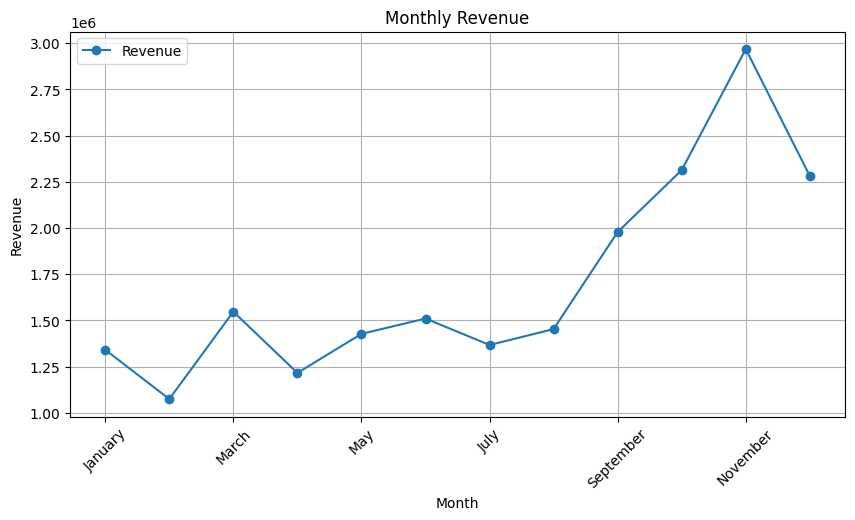

In [81]:
## Monthly Revenue
monthly_revenue.plot(
    x="Month",
    y="Revenue",
    kind="line",
    figsize=(10,5),
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

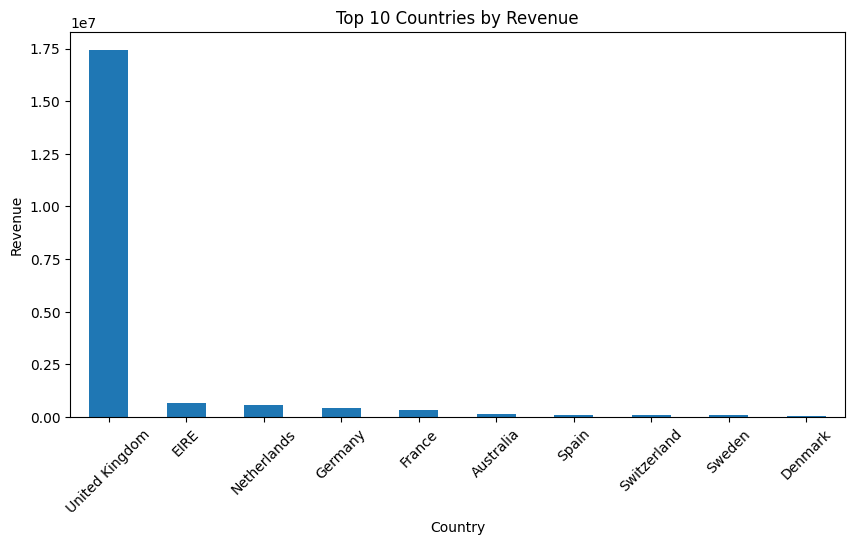

In [82]:
## Revenue by Country
country_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

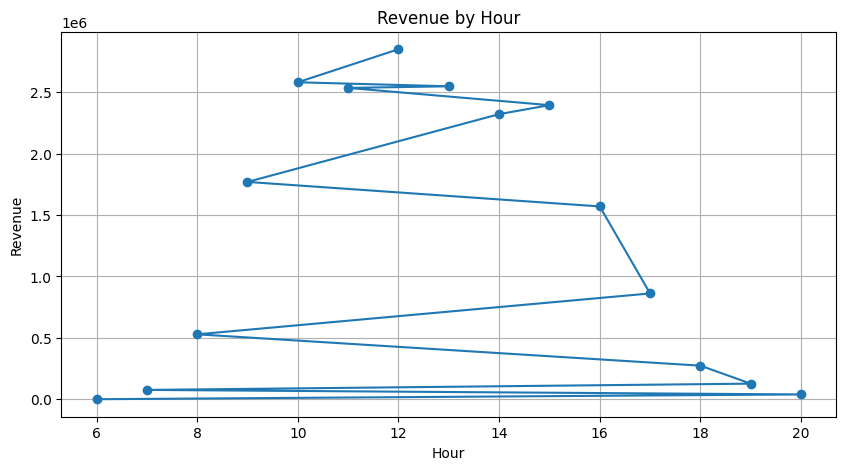

In [85]:
## Revenue By Hour
hour_revenue.plot(
    kind="line",
    figsize=(10,5),
    marker="o"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

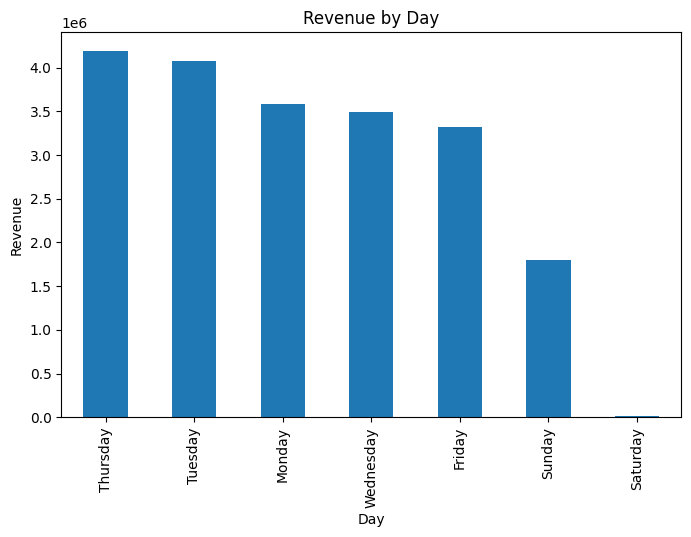

In [86]:
day_revenue.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Day")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.show()

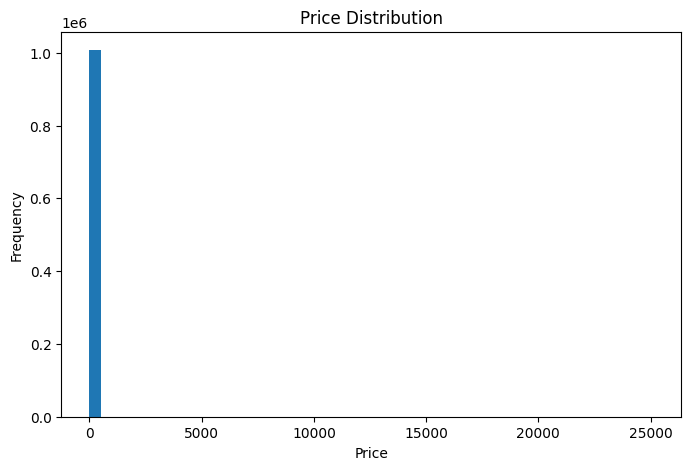

In [87]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

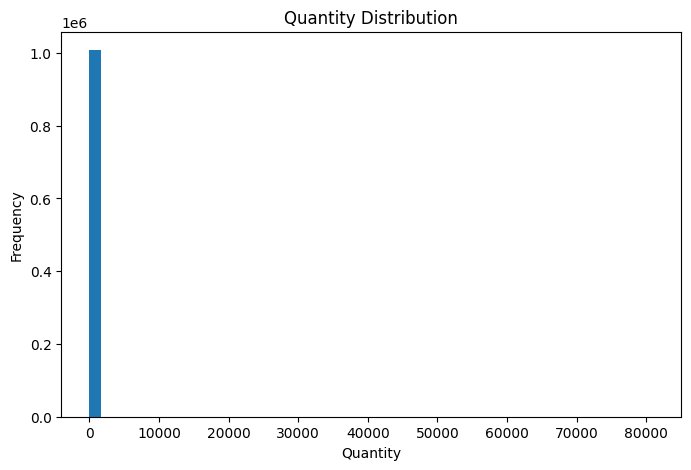

In [88]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=50)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

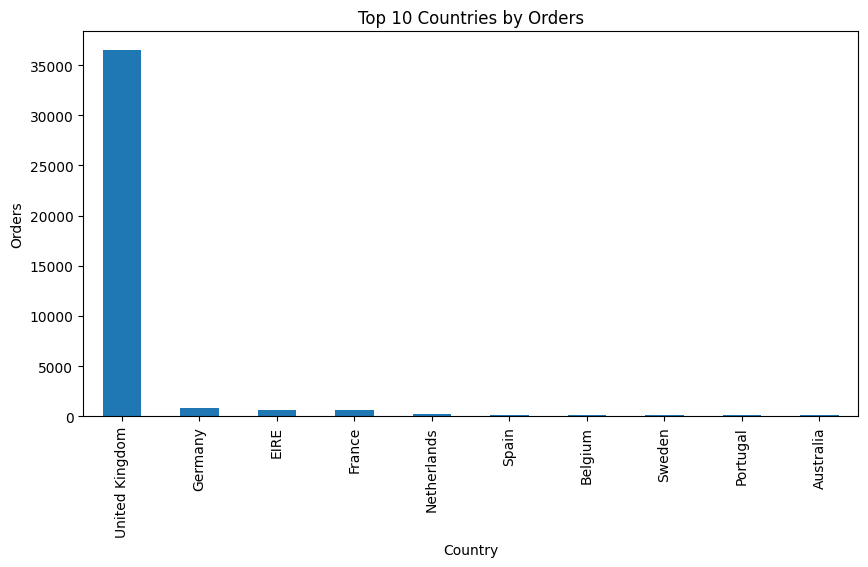

In [89]:
orders_country = df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False)

orders_country.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Orders")
plt.show()